In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

In [2]:
cursor.execute("""
CREATE TABLE departments(
    department_id INTEGER PRIMARY KEY,
    department_name TEXT
)
""")

cursor.execute("""
CREATE TABLE employees(
    employee_id INTEGER PRIMARY KEY,
    employee_name TEXT,
    age INTEGER,
    gender TEXT,
    salary REAL,
    department_id INTEGER,
    FOREIGN KEY(department_id) REFERENCES departments(department_id)
)
""")

In [3]:
departments = [
    (1,'IT'),
    (2,'HR'),
    (3,'Finance'),
    (4,'Marketing'),
    (5,'Operations')
]

cursor.executemany(
    "INSERT INTO departments VALUES (?,?)",
    departments
)

employees = [
(101,'Aarav',25,'Male',55000,1),
(102,'Priya',26,'Female',60000,1),
(103,'Rohit',30,'Male',45000,2),
(104,'Sneha',29,'Female',50000,2),
(105,'Arjun',28,'Male',75000,1),
(106,'Meera',31,'Female',68000,3),
(107,'Kiran',35,'Male',72000,4),
(108,'Divya',27,'Female',65000,1),
(109,'Rahul',32,'Male',48000,5),
(110,'Ananya',26,'Female',82000,1),
(111,'Vikram',33,'Male',70000,3),
(112,'Pooja',24,'Female',47000,2),
(113,'Suresh',29,'Male',76000,1),
(114,'Kavya',28,'Female',53000,4),
(115,'Ajay',27,'Male',62000,5),
(116,'Ritu',30,'Female',71000,3),
(117,'Manoj',34,'Male',45000,2),
(118,'Swati',25,'Female',80000,1),
(119,'Deepak',31,'Male',56000,5),
(120,'Nisha',26,'Female',69000,4),
(121,'Harish',29,'Male',64000,3),
(122,'Tanvi',27,'Female',85000,1)
]

In [4]:
cursor.executemany(
    "INSERT INTO employees VALUES (?,?,?,?,?,?)",
    employees
)

conn.commit()

query1 = """
SELECT d.department_name,
COUNT(*) AS total_employees,
AVG(e.salary) AS average_salary
FROM employees e
JOIN departments d
ON e.department_id=d.department_id
GROUP BY d.department_name
"""

print("\nDepartment Wise Analysis")
print(pd.read_sql_query(query1, conn))




Department Wise Analysis
  department_name  total_employees  average_salary
0         Finance                4    68250.000000
1              HR                4    46750.000000
2              IT                8    72250.000000
3       Marketing                3    64666.666667
4      Operations                3    55333.333333


In [5]:
query2 = """
SELECT d.department_name,
AVG(e.salary) AS avg_salary
FROM employees e
JOIN departments d
ON e.department_id=d.department_id
GROUP BY d.department_name
HAVING AVG(e.salary) > 60000
"""

print("\nDepartments With Average Salary Above 60000")
print(pd.read_sql_query(query2, conn))


Departments With Average Salary Above 60000
  department_name    avg_salary
0         Finance  68250.000000
1              IT  72250.000000
2       Marketing  64666.666667


In [6]:
query3 = """
SELECT employee_name,salary
FROM employees
WHERE salary >
(
SELECT AVG(salary)
FROM employees
)
ORDER BY salary DESC
"""

print("\nEmployees Earning Above Average Salary")
print(pd.read_sql_query(query3, conn))


Employees Earning Above Average Salary
   employee_name   salary
0          Tanvi  85000.0
1         Ananya  82000.0
2          Swati  80000.0
3         Suresh  76000.0
4          Arjun  75000.0
5          Kiran  72000.0
6           Ritu  71000.0
7         Vikram  70000.0
8          Nisha  69000.0
9          Meera  68000.0
10         Divya  65000.0
11        Harish  64000.0


In [7]:
query4 = """
SELECT
COUNT(*) AS total_employees,
AVG(salary) AS average_salary,
MAX(salary) AS highest_salary,
MIN(salary) AS lowest_salary,
SUM(salary) AS total_salary
FROM employees
"""

print("\nCompany Statistics")
print(pd.read_sql_query(query4, conn))


Company Statistics
   total_employees  average_salary  highest_salary  lowest_salary  \
0               22    63545.454545         85000.0        45000.0   

   total_salary  
0     1398000.0  


In [8]:
query5 = """
SELECT employee_name,salary
FROM employees
ORDER BY salary DESC
LIMIT 10
"""

print("\nTop 10 Highest Paid Employees")
print(pd.read_sql_query(query5, conn))



Top 10 Highest Paid Employees
  employee_name   salary
0         Tanvi  85000.0
1        Ananya  82000.0
2         Swati  80000.0
3        Suresh  76000.0
4         Arjun  75000.0
5         Kiran  72000.0
6          Ritu  71000.0
7        Vikram  70000.0
8         Nisha  69000.0
9         Meera  68000.0


In [9]:
dept_df = pd.read_sql_query("""
SELECT d.department_name,
AVG(e.salary) AS average_salary
FROM employees e
JOIN departments d
ON e.department_id=d.department_id
GROUP BY d.department_name
""", conn)


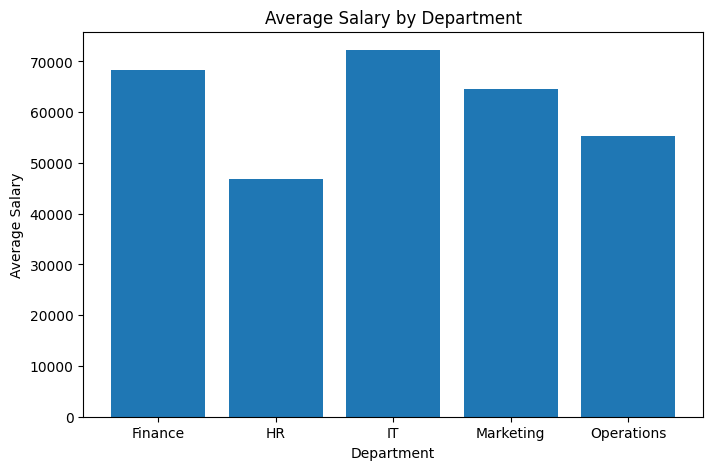

In [10]:
plt.figure(figsize=(8,5))
plt.bar(
    dept_df["department_name"],
    dept_df["average_salary"]
)
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

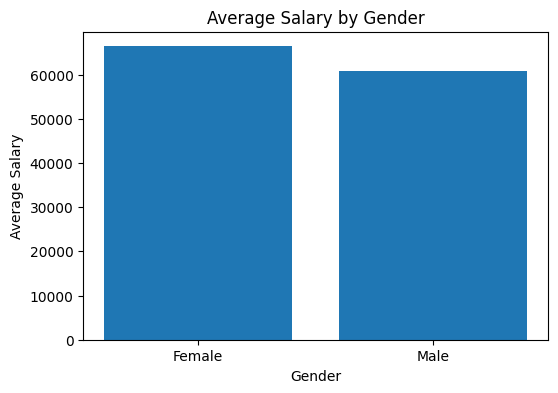

In [11]:
gender_df = pd.read_sql_query("""
SELECT gender,
AVG(salary) AS average_salary
FROM employees
GROUP BY gender
""", conn)

plt.figure(figsize=(6,4))
plt.bar(
    gender_df["gender"],
    gender_df["average_salary"]
)
plt.title("Average Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Salary")
plt.show()

conn.close()